# V10 & V10 DAF 2× — Two Best Strategies

This notebook implements the two top-performing sector rotation strategies identified through systematic research:

| Strategy | Sharpe | CAGR | Max DD | Avg Leverage |
|----------|--------|------|--------|--------------|
| **V10 1×** (Unleveraged) | 1.005 | 10.9% | −16.3% | 1.00× |
| **V10 DAF 2×/35** (Smart Leverage) | 1.058 | 14.2% | −15.1% | 1.28× |

**V10** = 50/50 ensemble of V4-Best (adaptive regime sectors) + V8-AW (All-Weather hedge rotation in bear).
**DAF 2×** = Dual-filter leverage: lever up to 2× only when BOTH realized vol is below its 35th percentile AND SPY > SMA200.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yfinance as yf
import time
from scipy import stats as scipy_stats

## Part 0 — Data & Universe

11 SPDR sector ETFs as the rotation universe, 5 hedge ETFs (TLT/GLD/UUP/FXY/FXF) used by V8-AW in bear regimes, SPY as benchmark, SHY (cash proxy).

In [2]:
# Universe
SECTOR_ETFS = ['XLK', 'XLF', 'XLV', 'XLE', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE', 'XLC']
HEDGE_ETFS  = ['TLT', 'GLD', 'UUP', 'FXY', 'FXF']
BENCHMARK   = 'SPY'
CASH_ETF    = 'SHY'
ALL_TICKERS = list(dict.fromkeys(SECTOR_ETFS + HEDGE_ETFS + [BENCHMARK, CASH_ETF]))

# Download ~20 years of daily closes
raw = yf.download(ALL_TICKERS, start='2004-07-01', end='2026-02-18',
                  progress=False, group_by='ticker')
closes = pd.DataFrame()
for t in ALL_TICKERS:
    try:
        c = raw[t]['Close']
        if isinstance(c, pd.DataFrame):
            c = c.iloc[:, 0]
        closes[t] = c
    except Exception:
        pass
closes = closes.sort_index().dropna(how='all')
print(f'Date range: {closes.index[0].date()} to {closes.index[-1].date()}')
print(f'Trading days: {len(closes)}')
print(f'Tickers loaded: {list(closes.columns)}')

Date range: 2004-07-01 to 2026-02-17
Trading days: 5442
Tickers loaded: ['XLK', 'XLF', 'XLV', 'XLE', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE', 'XLC', 'TLT', 'GLD', 'UUP', 'FXY', 'FXF', 'SPY', 'SHY']


In [3]:
# Download OHLC for ATR trend signal (needs High / Low)
ohlc_raw = yf.download(SECTOR_ETFS, start='2004-01-01', end='2026-02-18',
                       progress=False, group_by='ticker')
ohlc_dict = {}
for t in SECTOR_ETFS:
    try:
        df = ohlc_raw[t][['Open', 'High', 'Low', 'Close']].dropna()
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        ohlc_dict[t] = df
    except Exception:
        pass
print(f'OHLC loaded for {len(ohlc_dict)} tickers')

OHLC loaded for 11 tickers


## Part 0.1 — Signal Functions & Rank Matrices

Four ranking factors following Giordano (2018/2019):
- **Momentum**: 4-month rate of change
- **Volatility**: EWMA variance (RiskMetrics λ=0.94)
- **Correlation**: average pairwise correlation
- **Trend**: ATR-based breakout signal

Multi-horizon variants compute each signal at 3 lookbacks and average them.

In [4]:
# -- Signal computation functions --
# Each takes a DataFrame of closes (columns = tickers) and an integer row index,
# and returns a Series of raw signal values indexed by ticker.

def momentum_signal(closes, idx, lookback=84):
    """4-month rate of change. Higher = better."""
    if idx < lookback:
        return pd.Series(dtype=float)
    current = closes.iloc[idx]
    past    = closes.iloc[idx - lookback]
    return ((current - past) / past).dropna()


def ewma_volatility(closes, idx, lam=0.94, window=84):
    """EWMA volatility (RiskMetrics style). Lower = better."""
    if idx < window:
        return pd.Series(dtype=float)
    rets = closes.iloc[idx - window:idx + 1].pct_change().iloc[1:]  # drop first NaN row
    if len(rets) < 2:
        return pd.Series(dtype=float)
    var = rets.iloc[0] ** 2
    for t in range(1, len(rets)):
        var = lam * var + (1 - lam) * rets.iloc[t] ** 2
    return (np.sqrt(var * 252)).dropna()


def correlation_signal(closes, idx, lookback=84):
    """Average pairwise correlation over lookback window. Lower = better."""
    if idx < lookback:
        return pd.Series(dtype=float)
    rets = closes.iloc[idx - lookback:idx + 1].pct_change().iloc[1:]
    if len(rets) < 10:
        return pd.Series(dtype=float)
    corr_matrix = rets.corr()
    n = len(corr_matrix)
    avg_corr = (corr_matrix.sum(axis=1) - 1) / (n - 1)
    return avg_corr.dropna()


def trend_signal_atr(ohlc_dict, ticker, date, atr_period=42, high_period=63, low_period=105):
    """ATR breakout trend signal: +1 (uptrend), -1 (downtrend), 0 (neutral)."""
    try:
        df = ohlc_dict[ticker].loc[:date]
        if len(df) < max(atr_period, high_period, low_period):
            return 0
        h, l, c = df["High"], df["Low"], df["Close"]
        tr = pd.concat([h - l, (h - c.shift(1)).abs(), (l - c.shift(1)).abs()], axis=1).max(axis=1)
        atr = tr.rolling(atr_period).mean()
        upper = c.rolling(high_period).max() + atr
        lower = l.rolling(low_period).min() - atr
        last_c, last_u, last_l = float(c.iloc[-1]), float(upper.iloc[-1]), float(lower.iloc[-1])
        if last_c >= last_u: return 1
        elif last_c <= last_l: return -1
        else: return 0
    except Exception:
        return 0


# -- Multi-horizon signal functions (article author's modifications) --
HORIZONS = [21, 63, 126, 252]

def multi_momentum(closes, idx, horizons=HORIZONS):
    """Average momentum (ROC) across multiple lookback windows."""
    if idx < max(horizons):
        return pd.Series(dtype=float)
    current = closes.iloc[idx]
    rocs = [(current - closes.iloc[idx - h]) / closes.iloc[idx - h] for h in horizons]
    return pd.concat(rocs, axis=1).mean(axis=1).dropna()


def multi_volatility(closes, idx, horizons=HORIZONS):
    """Average historical volatility across multiple windows."""
    if idx < max(horizons):
        return pd.Series(dtype=float)
    rets = closes.pct_change()
    vols = [rets.iloc[idx - h:idx + 1].std() * np.sqrt(252) for h in horizons]
    return pd.concat(vols, axis=1).mean(axis=1).dropna()


def multi_correlation(closes, idx, horizons=HORIZONS):
    """Average pairwise correlation across multiple windows."""
    if idx < max(horizons):
        return pd.Series(dtype=float)
    rets = closes.pct_change()
    avg_corrs = []
    for h in horizons:
        cm = rets.iloc[idx - h:idx + 1].corr()
        avg_corrs.append((cm.sum(axis=1) - 1) / (len(cm) - 1))
    return pd.concat(avg_corrs, axis=1).mean(axis=1).dropna()


def multi_trend(closes, idx, horizons=HORIZONS):
    """Price / rolling high, averaged across windows. Higher = closer to highs."""
    if idx < max(horizons):
        return pd.Series(dtype=float)
    current = closes.iloc[idx]
    ratios = [current / closes.iloc[idx - h:idx + 1].max() for h in horizons]
    return pd.concat(ratios, axis=1).mean(axis=1).dropna()


print("Signal functions defined (original + multi-horizon)")


Signal functions defined (original + multi-horizon)


In [5]:
def build_rank_matrices(closes_df, ohlc_dict=None, mode="original"):
    """Build (days x tickers) rank matrices for all 4 signals + raw momentum.

    Returns:
        tickers: list of ticker names (column order)
        dates: DatetimeIndex of valid rows
        M_ranks, V_ranks, C_ranks, T_ranks: np.ndarray (n_days, n_tickers), float
        mom_raw: np.ndarray (n_days, n_tickers) -- raw momentum values (for cash filter)
        fwd_rets: np.ndarray (n_days, n_tickers) -- next-day returns
        cash_rets: np.ndarray (n_days,) -- next-day SHY returns
        bench_rets_arr: np.ndarray (n_days,) -- next-day SPY returns
        valid_mask: np.ndarray (n_days, n_tickers) bool -- True if data exists for that day
    """
    tickers = list(closes_df.columns)
    n_tickers = len(tickers)
    n_days = len(closes_df)

    # Determine warmup based on mode
    min_idx = 260 if mode == "multi" else 110

    # Preallocate NaN matrices
    M_ranks = np.full((n_days, n_tickers), np.nan)
    V_ranks = np.full((n_days, n_tickers), np.nan)
    C_ranks = np.full((n_days, n_tickers), np.nan)
    T_ranks = np.full((n_days, n_tickers), np.nan)
    mom_raw = np.full((n_days, n_tickers), np.nan)

    print(f"Building {mode} rank matrices ({n_days - min_idx} days, {n_tickers} tickers)...")

    for idx in range(min_idx, n_days):
        available = closes_df.columns[closes_df.iloc[idx].notna()].tolist()
        if len(available) < 3:
            continue
        sc = closes_df[available]

        if mode == "original":
            mom  = momentum_signal(sc, idx)
            vol  = ewma_volatility(sc, idx)
            corr = correlation_signal(sc, idx)
            common = mom.index.intersection(vol.index).intersection(corr.index)
            if len(common) < 3:
                continue
            # Ranks: lower = better
            m_r = mom[common].rank(ascending=False)
            v_r = vol[common].rank(ascending=True)
            c_r = corr[common].rank(ascending=True)
            # Trend: ATR signal (+1/0/-1), negate so that uptrend = lower "rank"
            date = sc.index[idx]
            t_vals = pd.Series({t: -trend_signal_atr(ohlc_dict, t, date) for t in common})
            for t in common:
                j = tickers.index(t)
                M_ranks[idx, j] = m_r[t]
                V_ranks[idx, j] = v_r[t]
                C_ranks[idx, j] = c_r[t]
                T_ranks[idx, j] = t_vals[t]
                mom_raw[idx, j] = mom[t]
        else:
            mom   = multi_momentum(sc, idx)
            vol   = multi_volatility(sc, idx)
            corr  = multi_correlation(sc, idx)
            trend = multi_trend(sc, idx)
            common = mom.index.intersection(vol.index).intersection(corr.index).intersection(trend.index)
            if len(common) < 3:
                continue
            m_r = mom[common].rank(ascending=False)
            v_r = vol[common].rank(ascending=True)
            c_r = corr[common].rank(ascending=True)
            t_r = trend[common].rank(ascending=False)
            for t in common:
                j = tickers.index(t)
                M_ranks[idx, j] = m_r[t]
                V_ranks[idx, j] = v_r[t]
                C_ranks[idx, j] = c_r[t]
                T_ranks[idx, j] = t_r[t]
                mom_raw[idx, j] = mom[t]

        if (idx - min_idx) % 500 == 0:
            print(f"  {idx - min_idx}/{n_days - min_idx}", end="\r")

    # Forward returns: tomorrow's return for each sector ETF
    rets_df = closes_df.pct_change().shift(-1).fillna(0)
    fwd_rets = rets_df.values  # (n_days, n_tickers)

    # Cash (SHY) and benchmark (SPY) next-day returns
    cash_r  = closes[CASH_ETF].pct_change().shift(-1).fillna(0).reindex(closes_df.index).fillna(0).values
    bench_r = closes[BENCHMARK].pct_change().shift(-1).fillna(0).reindex(closes_df.index).fillna(0).values

    valid_mask = ~np.isnan(M_ranks)  # True where we have valid ranks

    print(f"  Done. Valid days: {valid_mask.any(axis=1).sum()}")

    return {
        "tickers": tickers, "dates": closes_df.index,
        "M": M_ranks, "V": V_ranks, "C": C_ranks, "T": T_ranks,
        "mom": mom_raw, "fwd_rets": fwd_rets,
        "cash_rets": cash_r, "bench_rets": bench_r, "valid": valid_mask,
    }


# Build matrices for both modes


# Build matrices for both modes
sector_closes = closes[SECTOR_ETFS].dropna(how="all")
print("Precomputing rank matrices (one-time cost)...\n")
mat_orig  = build_rank_matrices(sector_closes, ohlc_dict, mode="original")
mat_multi = build_rank_matrices(sector_closes, ohlc_dict=None, mode="multi")

# Hedge ETFs (multi-horizon only)
available_hedge = [t for t in HEDGE_ETFS if t in closes.columns]
hedge_closes = closes[available_hedge].dropna(how="all")
mat_hedge = build_rank_matrices(hedge_closes, ohlc_dict=None, mode="multi")

print(f"\nOriginal: {mat_orig['valid'].any(axis=1).sum()} valid days")
print(f"Multi:    {mat_multi['valid'].any(axis=1).sum()} valid days")
print(f"Hedge:    {mat_hedge['valid'].any(axis=1).sum()} valid days")

Precomputing rank matrices (one-time cost)...

Building original rank matrices (5332 days, 11 tickers)...
  Done. Valid days: 5332
Building multi rank matrices (5182 days, 11 tickers)...
  Done. Valid days: 5182
Building multi rank matrices (5182 days, 5 tickers)...
  Done. Valid days: 4921

Original: 5332 valid days
Multi:    5182 valid days
Hedge:    4921 valid days


## Part 0.2 — Statistics & Cost Helpers

In [6]:
def compute_stats(equity, benchmark):
    """Compute key performance metrics."""
    sr = equity.pct_change().dropna()
    br = benchmark.pct_change().dropna()
    n_yr = len(sr) / 252
    if n_yr <= 0:
        return pd.DataFrame()

    cagr_s = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_yr) - 1
    cagr_b = (benchmark.iloc[-1] / benchmark.iloc[0]) ** (1 / n_yr) - 1
    vol_s, vol_b = sr.std() * np.sqrt(252), br.std() * np.sqrt(252)
    sh_s = cagr_s / vol_s if vol_s > 0 else 0
    sh_b = cagr_b / vol_b if vol_b > 0 else 0

    def mdd(eq):
        pk = eq.cummax()
        return ((eq - pk) / pk).min()
    md_s, md_b = mdd(equity), mdd(benchmark)
    cal_s = -cagr_s / md_s if md_s < 0 else 0
    cal_b = -cagr_b / md_b if md_b < 0 else 0
    wr = (sr.resample("ME").sum() > 0).mean()

    return pd.DataFrame({
        "Strategy": [f"{cagr_s:.1%}", f"{vol_s:.1%}", f"{sh_s:.2f}",
                     f"{md_s:.1%}", f"{cal_s:.2f}", f"{wr:.1%}", f"{equity.iloc[-1]:.2f}"],
        "SPY": [f"{cagr_b:.1%}", f"{vol_b:.1%}", f"{sh_b:.2f}",
                f"{md_b:.1%}", f"{cal_b:.2f}", "-", f"{benchmark.iloc[-1]:.2f}"],
    }, index=["CAGR", "Volatility", "Sharpe", "Max Drawdown", "Calmar",
             "Monthly Win Rate", "Final Value ($1)"])


def compute_full_stats(equity, benchmark):
    """Extended stats including Sortino, Skew, Kurtosis, PSR."""
    sr = equity.pct_change().dropna()
    br = benchmark.pct_change().dropna()
    n_yr = len(sr) / 252

    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_yr) - 1
    cagr_b = (benchmark.iloc[-1] / benchmark.iloc[0]) ** (1 / n_yr) - 1
    vol = sr.std() * np.sqrt(252)
    vol_b = br.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    sharpe_b = cagr_b / vol_b if vol_b > 0 else 0

    pk = equity.cummax()
    dd = ((equity - pk) / pk).min()
    pk_b = benchmark.cummax()
    dd_b = ((benchmark - pk_b) / pk_b).min()
    calmar = -cagr / dd if dd < 0 else 0

    down = sr[sr < 0]
    down_std = down.std() * np.sqrt(252)
    sortino = cagr / down_std if down_std > 0 else 0

    wr = (sr.resample("ME").sum() > 0).mean()
    skew = float(scipy_stats.skew(sr))
    kurt = float(scipy_stats.kurtosis(sr))

    # PSR: probability true Sharpe > 0
    n = len(sr)
    sr_hat = sharpe / np.sqrt(252)  # daily Sharpe
    denom = np.sqrt(1 - skew * sr_hat + (kurt - 1) / 4 * sr_hat ** 2)
    psr = float(scipy_stats.norm.cdf(sr_hat * np.sqrt(n - 1) / denom)) if denom > 0 else 0.5

    return {
        "CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "Max DD": dd,
        "Calmar": calmar, "Sortino": sortino, "Win Rate": wr,
        "Skew": skew, "Kurtosis": kurt, "PSR": psr, "Final": equity.iloc[-1],
    }


# Rebuild adaptive results


def apply_transaction_costs(equity, allocations, cost_bps=10):
    """Apply round-trip transaction costs at each rebalance."""
    eq = equity.copy()
    cost = cost_bps / 10000
    prev_alloc = {}
    for date, alloc in allocations:
        if date not in eq.index:
            continue
        all_tickers = set(list(prev_alloc.keys()) + list(alloc.keys()))
        turnover = sum(abs(alloc.get(t, 0) - prev_alloc.get(t, 0)) for t in all_tickers) / 2
        cost_drag = 1 - cost * turnover * 2
        idx = eq.index.get_loc(date)
        eq.iloc[idx:] *= cost_drag
        prev_alloc = alloc
    return eq


def quick_stats(r, cost_bps=10):
    """Return (sharpe_10bp, cagr_10bp, maxdd, beat_spy_count, total_years, vol)."""
    if r is None:
        return (-999, 0, 0, 0, 0, 0)
    eq, bm = r["equity"], r["benchmark"]
    allocs = r.get("allocations", [])
    eq_c = apply_transaction_costs(eq, allocs, cost_bps=cost_bps)
    sr = eq_c.pct_change().dropna()
    n_yr = len(sr) / 252
    if n_yr <= 0:
        return (-999, 0, 0, 0, 0, 0)
    cagr = (eq_c.iloc[-1] / eq_c.iloc[0]) ** (1 / n_yr) - 1
    vol = sr.std() * np.sqrt(252)
    sh = cagr / vol if vol > 0 else 0
    pk = eq_c.cummax(); dd = ((eq_c - pk) / pk).min()
    strat_yr = eq_c.resample("YE").last().pct_change().dropna()
    spy_yr   = bm.resample("YE").last().pct_change().dropna()
    common = strat_yr.index.intersection(spy_yr.index)
    beats = int((strat_yr[common] > spy_yr[common]).sum())
    return (sh, cagr, dd, beats, len(common), vol)


def fmt_full_stats(stats, label='Strategy'):
    """Format a compute_full_stats dict into a display-ready DataFrame."""
    d = {}
    for k, v in stats.items():
        if k in ('CAGR', 'Vol', 'Win Rate'):
            d[k] = f'{v:.1%}'
        elif k == 'Max DD':
            d[k] = f'{v:.1%}'
        elif k in ('Sharpe', 'Calmar', 'Sortino'):
            d[k] = f'{v:.3f}'
        elif k == 'PSR':
            d[k] = f'{v:.1%}'
        elif k == 'Final':
            d[k] = f'${v:.2f}'
        else:
            d[k] = f'{v:.2f}'
    return pd.Series(d, name=label)


## Part 0.3 — Strategy Engines

Three engine functions required to build V10:
1. **adaptive_backtest_v4** — regime-conditional sector rotation with conviction overweighting
2. **adaptive_backtest_v8aw** — All-Weather variant: concentrated sectors in bull/neutral, rotates into hedge ETFs (TLT/GLD/…) in bear
3. **ensemble_blend** — averages daily returns of any set of strategy results

In [7]:
def adaptive_backtest_v4(mat, weights=(0.25, 0.25, 0.25, 0.25),
                         top_n_bull=8, top_n_neutral=5, top_n_bear=3,
                         rebal_freq="M", breadth_thr=0.6,
                         sizing="equal", vol_lookback=63,
                         cash_filter_bull=False, cash_filter_neutral=True, cash_filter_bear=True,
                         # V4 new parameters
                         conviction_overweight=False, conviction_threshold=2.0,
                         conviction_top_pct=0.40,
                         sector_sma50_filter=False,
                         recovery_accel=False, recovery_extra_n=3, recovery_months=3,
                         neutral_mom_threshold=0.0):
    """
    V4: Targeted improvements based on year-loss attribution.

    New features:
      conviction_overweight: If True, #1 ranked sector gets conviction_top_pct weight
                             when its score is >conviction_threshold σ below mean
      sector_sma50_filter:   If True, skip sectors trading below their 50-day SMA
                             (replace with next-best sector, NOT cash)
      recovery_accel:        If True, expand top_n by recovery_extra_n during first
                             recovery_months months after bear→bull transition
      neutral_mom_threshold: Cash filter threshold in neutral regime (default 0 = any
                             negative momentum → cash; set to e.g. -0.05 for softer)
    """
    wM, wV, wC, wT = weights
    M, V, C, T = mat["M"], mat["V"], mat["C"], mat["T"]
    mom_mat, fwd, cash_r, bench_r = mat["mom"], mat["fwd_rets"], mat["cash_rets"], mat["bench_rets"]
    valid = mat["valid"]
    mat_dates = mat["dates"]
    tickers = mat["tickers"]
    n_days, n_tickers = M.shape

    # Regime indicators
    spy_p = closes["SPY"].reindex(mat_dates).ffill().values
    spy_sma_arr = pd.Series(spy_p, index=mat_dates).rolling(200).mean().values
    sec_p = closes[SECTOR_ETFS].reindex(mat_dates).ffill()
    sec_sma50 = sec_p.rolling(50).mean()
    breadth_arr = (sec_p > sec_sma50).sum(axis=1).values / sec_p.notna().sum(axis=1).values

    # Per-sector SMA50 (for sector_sma50_filter)
    if sector_sma50_filter:
        sector_above_sma50 = (sec_p > sec_sma50).values  # (n_days, n_sectors)
        sec_to_idx = {t: SECTOR_ETFS.index(t) for t in tickers if t in SECTOR_ETFS}
    else:
        sector_above_sma50 = None
        sec_to_idx = None

    # Precompute for inv_vol
    sec_rets = closes[SECTOR_ETFS].reindex(mat_dates).ffill().pct_change()
    rolling_vol = sec_rets.rolling(vol_lookback, min_periods=20).std().values * np.sqrt(252)
    tick_to_sec = {t: SECTOR_ETFS.index(t) for t in tickers if t in SECTOR_ETFS}

    # Composite
    big = 9999.0
    composite = (wM * np.where(valid, M, big) +
                 wV * np.where(valid, V, big) +
                 wC * np.where(valid, C, big) +
                 wT * np.where(valid, T, big))

    valid_days_arr = np.where(valid.any(axis=1))[0]
    if len(valid_days_arr) == 0:
        return None
    first, last = valid_days_arr[0], valid_days_arr[-1]
    if last - first < 20:
        return None

    # Rebalance schedule
    active_dates = mat_dates[first:last + 1]
    rebal_mask = np.zeros(n_days, dtype=bool)
    if rebal_freq == "W":
        rd = pd.Series(active_dates).groupby(active_dates.to_period("W")).last().values
    elif rebal_freq == "2W":
        wk = pd.Series(active_dates).groupby(active_dates.to_period("W")).last()
        rd = wk.iloc[::2].values
    else:
        rd = pd.Series(active_dates).groupby(active_dates.to_period("M")).last().values
    for d in rd:
        loc = mat_dates.get_indexer([d], method="ffill")[0]
        if first <= loc <= last:
            rebal_mask[loc] = True
    rebal_mask[first] = True

    # Recovery tracking: detect bear→bull transitions
    last_bear_end = -9999  # day index when bear last ended

    # Main loop
    port_weights = np.zeros((n_days, n_tickers))
    cash_weight = np.zeros(n_days)
    alloc_list = []
    current_w = np.zeros(n_tickers)
    current_cash = 1.0
    prev_regime = "N"

    for i in range(first, last + 1):
        if rebal_mask[i]:
            s_p, s_sma, br = spy_p[i], spy_sma_arr[i], breadth_arr[i]
            if np.isnan(s_sma):
                regime = "N"
            elif s_p > s_sma and br >= breadth_thr:
                regime = "B"
            elif s_p > s_sma:
                regime = "N"
            else:
                regime = "D"

            # Track bear→bull transitions for recovery acceleration
            if prev_regime == "D" and regime in ("B", "N"):
                last_bear_end = i
            prev_regime = regime

            # Determine top_n based on regime
            if regime == "B":
                top_n = top_n_bull
                use_cf = cash_filter_bull
                mom_thr = 0.0  # not used when cf is off
            elif regime == "N":
                top_n = top_n_neutral
                use_cf = cash_filter_neutral
                mom_thr = neutral_mom_threshold
            else:
                top_n = top_n_bear
                use_cf = cash_filter_bear
                mom_thr = 0.0

            # Recovery acceleration: expand top_n after bear→bull
            if recovery_accel and (i - last_bear_end) < recovery_months * 21:
                top_n = min(top_n + recovery_extra_n, n_tickers)

            row = composite[i]
            valid_count = valid[i].sum()
            if valid_count < top_n:
                current_w = np.zeros(n_tickers)
                current_cash = 1.0
            else:
                # Sort all valid tickers by composite score
                valid_idx = np.where(valid[i])[0]
                sorted_valid = valid_idx[np.argsort(row[valid_idx])]

                # Apply sector SMA50 filter: skip sectors below their SMA50
                if sector_sma50_filter and sector_above_sma50 is not None:
                    filtered = []
                    for j in sorted_valid:
                        t = tickers[j]
                        if t in sec_to_idx:
                            if sector_above_sma50[i, sec_to_idx[t]]:
                                filtered.append(j)
                            # Skip this sector, try next best
                        else:
                            filtered.append(j)  # non-sector tickers pass through
                        if len(filtered) >= top_n:
                            break
                    # If we couldn't fill top_n, take what we have
                    top_idx = np.array(filtered[:top_n]) if len(filtered) > 0 else sorted_valid[:top_n]
                else:
                    top_idx = sorted_valid[:top_n]

                n_selected = len(top_idx)

                # ── Sizing ──
                if sizing == "inv_vol":
                    raw_w = np.zeros(n_selected)
                    for k, j in enumerate(top_idx):
                        t = tickers[j]
                        if t in tick_to_sec:
                            v = rolling_vol[i, tick_to_sec[t]]
                            raw_w[k] = 1.0 / v if (not np.isnan(v) and v > 0) else 1.0
                        else:
                            raw_w[k] = 1.0
                elif sizing == "mom_prop":
                    raw_w = np.zeros(n_selected)
                    for k, j in enumerate(top_idx):
                        m = mom_mat[i, j]
                        raw_w[k] = max(m, 0.001) if not np.isnan(m) else 0.001
                elif sizing == "ranked":
                    raw_w = np.zeros(n_selected)
                    for k in range(n_selected):
                        raw_w[k] = n_selected - k  # best rank gets highest weight
                else:  # equal
                    raw_w = np.ones(n_selected)

                # ── Conviction overweight ──
                if conviction_overweight and n_selected >= 2:
                    scores = row[top_idx]
                    mean_score = scores.mean()
                    std_score = scores.std()
                    if std_score > 0:
                        best_z = (mean_score - scores[0]) / std_score  # positive = better
                        if best_z > conviction_threshold:
                            # Top-1 gets conviction_top_pct, rest share the remainder
                            raw_w = np.ones(n_selected)
                            total_rest = (1.0 - conviction_top_pct) / (n_selected - 1) if n_selected > 1 else 0
                            raw_w[0] = conviction_top_pct
                            raw_w[1:] = total_rest
                            # Skip normal normalization
                            total_w = raw_w.sum()
                            if abs(total_w - 1.0) > 0.001:
                                raw_w /= total_w

                total_w = raw_w.sum()
                if total_w > 0:
                    raw_w /= total_w
                else:
                    raw_w = np.full(n_selected, 1.0 / n_selected)

                new_w = np.zeros(n_tickers)
                new_cash = 0.0
                holdings = {}
                for k, j in enumerate(top_idx):
                    m_val = mom_mat[i, j]
                    if use_cf and (np.isnan(m_val) or m_val < mom_thr):
                        new_cash += raw_w[k]
                        holdings[CASH_ETF] = holdings.get(CASH_ETF, 0) + raw_w[k]
                    else:
                        new_w[j] = raw_w[k]
                        holdings[tickers[j]] = raw_w[k]
                current_w = new_w
                current_cash = new_cash
                alloc_list.append((mat_dates[i], holdings))

        port_weights[i] = current_w
        cash_weight[i] = current_cash

    port_daily = (port_weights[first:last+1] * fwd[first:last+1]).sum(axis=1) + \
                  cash_weight[first:last+1] * cash_r[first:last+1]
    bench_daily = bench_r[first:last+1]
    eq_vals = np.cumprod(1 + port_daily)
    bm_vals = np.cumprod(1 + bench_daily)
    eq_vals = np.insert(eq_vals, 0, 1.0)
    bm_vals = np.insert(bm_vals, 0, 1.0)
    dt_index = mat_dates[first:last + 1]
    dt_index = dt_index.insert(0, mat_dates[max(0, first - 1)])

    equity = pd.Series(eq_vals, index=dt_index[:len(eq_vals)], name="Strategy")
    bench  = pd.Series(bm_vals, index=dt_index[:len(bm_vals)], name="SPY")

    return {"equity": equity, "benchmark": bench,
            "allocations": alloc_list, "stats": compute_stats(equity, bench)}

In [8]:
def adaptive_backtest_v8aw(mat, mat_hedge_data, weights=(0.1, 0.2, 0.25, 0.45),
                           top_n_bull=3, top_n_neutral=3, top_n_bear_hedge=2,
                           rebal_freq="M", breadth_thr=0.5,
                           neutral_mom_threshold=-0.03, cash_filter_neutral=True,
                           hedge_lookback=63):
    """
    V8-AW: "All-Weather" variant.
    Bull: concentrated top sectors (like V8)
    Bear: rotate into best HEDGE ETFs by momentum (TLT, GLD, etc.)
    instead of just parking in SHY.
    
    Key difference from V8: bear markets earn TLT/GLD returns (~5-15%)
    instead of SHY returns (~2-3%). This could boost CAGR significantly.
    """
    wM, wV, wC, wT = weights
    M, V, C, T = mat["M"], mat["V"], mat["C"], mat["T"]
    mom_mat = mat["mom"]
    fwd, cash_r, bench_r = mat["fwd_rets"], mat["cash_rets"], mat["bench_rets"]
    valid = mat["valid"]
    mat_dates = mat["dates"]
    tickers = mat["tickers"]
    n_days, n_tickers = M.shape

    # Hedge ETF data (precomputed)
    hedge_tickers = mat_hedge_data["tickers"]
    hedge_fwd = mat_hedge_data["fwd_rets"]
    hedge_dates = mat_hedge_data["dates"]
    n_hedge = len(hedge_tickers)
    
    # Build hedge momentum for ranking
    hedge_closes_df = closes[hedge_tickers].reindex(mat_dates).ffill()
    hedge_mom = (hedge_closes_df / hedge_closes_df.shift(hedge_lookback) - 1).values

    spy_p = closes["SPY"].reindex(mat_dates).ffill().values
    spy_sma_arr = pd.Series(spy_p, index=mat_dates).rolling(200).mean().values
    sec_p = closes[SECTOR_ETFS].reindex(mat_dates).ffill()
    sec_sma50 = sec_p.rolling(50).mean()
    breadth_arr = (sec_p > sec_sma50).sum(axis=1).values / sec_p.notna().sum(axis=1).values

    # Sector composite
    big = 9999.0
    composite = (wM * np.where(valid, M, big) +
                 wV * np.where(valid, V, big) +
                 wC * np.where(valid, C, big) +
                 wT * np.where(valid, T, big))

    # Hedge forward returns aligned to mat_dates
    hedge_fwd_aligned = np.zeros((n_days, n_hedge))
    for hi, ht in enumerate(hedge_tickers):
        h_rets = closes[ht].reindex(mat_dates).ffill().pct_change().shift(-1).fillna(0).values
        hedge_fwd_aligned[:, hi] = h_rets

    valid_days_arr = np.where(valid.any(axis=1))[0]
    if len(valid_days_arr) == 0:
        return None
    first, last = valid_days_arr[0], valid_days_arr[-1]
    if last - first < 20:
        return None

    active_dates = mat_dates[first:last + 1]
    rebal_mask = np.zeros(n_days, dtype=bool)
    if rebal_freq == "W":
        rd = pd.Series(active_dates).groupby(active_dates.to_period("W")).last().values
    elif rebal_freq == "2W":
        wk = pd.Series(active_dates).groupby(active_dates.to_period("W")).last()
        rd = wk.iloc[::2].values
    else:
        rd = pd.Series(active_dates).groupby(active_dates.to_period("M")).last().values
    for d in rd:
        loc = mat_dates.get_indexer([d], method="ffill")[0]
        if first <= loc <= last:
            rebal_mask[loc] = True
    rebal_mask[first] = True

    port_weights = np.zeros((n_days, n_tickers))
    hedge_weights = np.zeros((n_days, n_hedge))
    cash_weight = np.zeros(n_days)
    alloc_list = []
    current_w = np.zeros(n_tickers)
    current_hw = np.zeros(n_hedge)
    current_cash = 1.0

    for i in range(first, last + 1):
        if rebal_mask[i]:
            s_p, s_sma, br = spy_p[i], spy_sma_arr[i], breadth_arr[i]
            if np.isnan(s_sma):
                regime = "N"
            elif s_p > s_sma and br >= breadth_thr:
                regime = "B"
            elif s_p > s_sma:
                regime = "N"
            else:
                regime = "D"

            new_w = np.zeros(n_tickers)
            new_hw = np.zeros(n_hedge)
            new_cash = 0.0
            holdings = {}

            if regime == "D":
                # BEAR: rotate into best hedge ETFs by momentum
                h_mom = hedge_mom[i]
                valid_h = ~np.isnan(h_mom)
                if valid_h.sum() >= top_n_bear_hedge:
                    sorted_h = np.argsort(-h_mom)  # descending by momentum
                    top_h = [j for j in sorted_h if valid_h[j]][:top_n_bear_hedge]
                    w_per = 1.0 / len(top_h)
                    for j in top_h:
                        new_hw[j] = w_per
                        holdings[hedge_tickers[j]] = w_per
                else:
                    new_cash = 1.0
                    holdings[CASH_ETF] = 1.0
            else:
                # BULL / NEUTRAL: concentrated sectors (like V8)
                if regime == "B":
                    top_n = top_n_bull
                    use_cf = False
                    mom_thr = 0.0
                else:
                    top_n = top_n_neutral
                    use_cf = cash_filter_neutral
                    mom_thr = neutral_mom_threshold

                row = composite[i]
                valid_count = valid[i].sum()
                if valid_count < top_n:
                    new_cash = 1.0
                else:
                    valid_idx = np.where(valid[i])[0]
                    sorted_valid = valid_idx[np.argsort(row[valid_idx])]
                    top_idx = sorted_valid[:top_n]
                    w_per = 1.0 / top_n
                    for j in top_idx:
                        m_val = mom_mat[i, j]
                        if use_cf and (np.isnan(m_val) or m_val < mom_thr):
                            new_cash += w_per
                            holdings[CASH_ETF] = holdings.get(CASH_ETF, 0) + w_per
                        else:
                            new_w[j] = w_per
                            holdings[tickers[j]] = w_per

            current_w = new_w
            current_hw = new_hw
            current_cash = new_cash
            alloc_list.append((mat_dates[i], holdings))

        port_weights[i] = current_w
        hedge_weights[i] = current_hw
        cash_weight[i] = current_cash

    # Portfolio daily returns = sector returns + hedge returns + cash
    port_daily = (
        (port_weights[first:last+1] * fwd[first:last+1]).sum(axis=1) +
        (hedge_weights[first:last+1] * hedge_fwd_aligned[first:last+1]).sum(axis=1) +
        cash_weight[first:last+1] * cash_r[first:last+1]
    )
    bench_daily = bench_r[first:last+1]
    eq_vals = np.cumprod(1 + port_daily)
    bm_vals = np.cumprod(1 + bench_daily)
    eq_vals = np.insert(eq_vals, 0, 1.0)
    bm_vals = np.insert(bm_vals, 0, 1.0)
    dt_index = mat_dates[first:last + 1]
    dt_index = dt_index.insert(0, mat_dates[max(0, first - 1)])
    equity = pd.Series(eq_vals, index=dt_index[:len(eq_vals)], name="Strategy")
    bench  = pd.Series(bm_vals, index=dt_index[:len(bm_vals)], name="SPY")
    return {"equity": equity, "benchmark": bench,
            "allocations": alloc_list, "stats": compute_stats(equity, bench)}

In [9]:
def ensemble_blend(results_dict, blend_weights=None):
    """
    V10: Equal-weight (or custom-weight) ensemble of multiple strategies.
    
    Diversifying ACROSS strategies reduces strategy-specific risk:
    if V4 loses in 2023 but V6 wins, the blend is more stable.
    """
    names = list(results_dict.keys())
    if blend_weights is None:
        blend_weights = {n: 1.0 / len(names) for n in names}
    
    # Align all equity/benchmark series to common dates
    all_eq = pd.DataFrame({n: r["equity"] for n, r in results_dict.items()})
    all_bm = pd.DataFrame({n: r["benchmark"] for n, r in results_dict.items()})
    
    # Drop dates where any strategy has NaN
    all_eq = all_eq.dropna()
    all_bm = all_bm.dropna()
    
    # Compute daily returns for each
    eq_rets = all_eq.pct_change().dropna()
    bm_rets = all_bm.iloc[:, 0].pct_change().dropna()
    
    # Blend returns
    blended_rets = sum(blend_weights[n] * eq_rets[n] for n in names)
    
    # Rebuild equity
    common_start = eq_rets.index[0]
    eq_start_idx = all_eq.index.get_loc(common_start) - 1 if common_start != all_eq.index[0] else 0
    blended_eq = (1 + blended_rets).cumprod()
    blended_eq = pd.concat([pd.Series([1.0], index=[all_eq.index[eq_start_idx]]), blended_eq])
    blended_eq.name = "Strategy"
    
    bench_eq = (1 + bm_rets).cumprod()
    bench_eq = pd.concat([pd.Series([1.0], index=[all_eq.index[eq_start_idx]]), bench_eq])
    bench_eq.name = "SPY"
    
    # Merge all allocations for cost estimation
    all_allocs = []
    for n, r in results_dict.items():
        w = blend_weights[n]
        for date, alloc in r["allocations"]:
            scaled_alloc = {k: v * w for k, v in alloc.items()}
            all_allocs.append((date, scaled_alloc))
    all_allocs.sort(key=lambda x: x[0])
    
    return {"equity": blended_eq, "benchmark": bench_eq,
            "allocations": all_allocs,
            "stats": compute_stats(blended_eq, bench_eq)}

## Part 0.4 — DAF Leverage Function

**Dual-Filter Leverage (DAF)**: applies `max_lev` only when BOTH:
1. Portfolio realized volatility < `vol_pct`-th percentile of its history
2. SPY > its 200-day SMA (bull regime)

Otherwise stays at 1×.  A 1-day information lag prevents look-ahead.

In [10]:
_shy_full = closes[CASH_ETF].ffill().pct_change().fillna(0)


def apply_dual_filter_leverage(result, max_lev=1.5, vol_lb=21, vol_pct=50,
                                spread_annual=0.005):
    """
    Apply max_lev only when BOTH:
      (1) Realized vol < rolling vol_pct-th percentile (quiet markets)
      (2) SPY > SMA200 (bull regime)
    1-day lag — no look-ahead.
    """
    eq = result["equity"]; bm = result["benchmark"]
    sr = eq.pct_change().dropna()
    rv      = sr.rolling(vol_lb, min_periods=5).std() * np.sqrt(252)
    low_vol = rv < rv.expanding().quantile(vol_pct / 100)
    spy_p   = closes["SPY"].reindex(sr.index).ffill()
    bull    = spy_p > spy_p.rolling(200, min_periods=50).mean()
    lev_s = pd.Series(1.0, index=sr.index)
    lev_s[low_vol & bull] = max_lev
    lev_s = lev_s.shift(1).fillna(1.0)
    shy    = _shy_full.reindex(sr.index).fillna(0)
    borrow = (lev_s - 1).clip(lower=0) * (shy + spread_annual / 252)
    lev_r  = lev_s * sr - borrow
    lev_eq = pd.concat([pd.Series([1.0], index=[eq.index[0]]), (1 + lev_r).cumprod()])
    lev_eq.name = "Strategy"
    bm_eq  = pd.concat([pd.Series([1.0], index=[bm.index[0]]),
                        (1 + bm.pct_change().dropna()).cumprod()]); bm_eq.name = "SPY"
    return {"equity": lev_eq, "benchmark": bm_eq,
            "allocations": result.get("allocations", []),
            "stats": compute_stats(lev_eq, bm_eq), "avg_leverage": float(lev_s.mean())}


---

## Part 1 — Strategy 1: V10 1× (Unleveraged)

**V10 = 50/50 ensemble of V4-Best + V8-AW Best**

### V4-Best parameters (from full grid search — hardcoded here for reproducibility)
```
weights = (0.1, 0.2, 0.25, 0.45)  # Momentum, Volatility, Correlation, Trend
top_n_bull=6, top_n_neutral=5, top_n_bear=2
breadth_thr=0.5, conv_overweight=True, conv_threshold=2.0, conv_top_pct=0.5
neutral_mom_threshold=-0.03
```

### V8-AW Best parameters (found via grid below)
```
weights = (0.1, 0.2, 0.25, 0.45)
top_n_bull=6, top_n_neutral=4, top_n_bear_hedge=2
breadth_thr=0.5, neutral_mom_threshold=-0.03, hedge_lookback=63
```

In [11]:
# ── Build V4-Best ────────────────────────────────────────────────────────
print('Building V4-Best...', end=' ')
t0 = time.time()
r_v4_best = adaptive_backtest_v4(
    mat_orig,
    weights=(0.1, 0.2, 0.25, 0.45),
    top_n_bull=6, top_n_neutral=5, top_n_bear=2,
    rebal_freq='M', breadth_thr=0.5, sizing='equal',
    cash_filter_bull=False, cash_filter_neutral=True, cash_filter_bear=True,
    conviction_overweight=True, conviction_threshold=2.0, conviction_top_pct=0.5,
    neutral_mom_threshold=-0.03,
)
print(f'done in {time.time()-t0:.1f}s')
qs = quick_stats(r_v4_best)
print(f'V4-Best: Sharpe={qs[0]:.3f}, CAGR={qs[1]:.1%}, MaxDD={qs[2]:.1%}, '
      f'Beats={qs[3]}/{qs[4]}')

Building V4-Best... done in 0.1s
V4-Best: Sharpe=0.956, CAGR=10.8%, MaxDD=-19.6%, Beats=10/22


In [12]:
# ── V8-AW Grid Search (find best params) ───────────────────────────────────
hedge_data = {
    'tickers': [t for t in HEDGE_ETFS if t in closes.columns],
    'fwd_rets': mat_hedge['fwd_rets'],
    'dates': mat_hedge['dates'],
}

print('Running V8-AW grid search...')
t0 = time.time()
v8aw_grid = []
for bn_bull in [4, 5, 6]:
    for bn_hedge in [1, 2, 3]:
        for br_thr in [0.4, 0.5, 0.6]:
            for hlb in [42, 63, 126]:
                for mt in [0.0, -0.03]:
                    for w in [(0.1, 0.2, 0.25, 0.45), (0.15, 0.15, 0.2, 0.5)]:
                        r = adaptive_backtest_v8aw(
                            mat_orig, hedge_data,
                            weights=w, top_n_bull=bn_bull,
                            top_n_neutral=min(bn_bull, 4),
                            top_n_bear_hedge=bn_hedge,
                            rebal_freq='M', breadth_thr=br_thr,
                            neutral_mom_threshold=mt,
                            hedge_lookback=hlb,
                        )
                        if r is None:
                            continue
                        sh, cagr, dd, beats, total, vol = quick_stats(r)
                        v8aw_grid.append(dict(
                            weights=w, bull_n=bn_bull, hedge_n=bn_hedge,
                            br_thr=br_thr, hedge_lb=hlb, mom_thr=mt,
                            sharpe=sh, cagr=cagr, vol=vol, maxdd=dd,
                            beats=beats, total=total, _r=r,
                        ))

df_v8aw = pd.DataFrame(v8aw_grid)
best_aw = df_v8aw.loc[df_v8aw['sharpe'].idxmax()]
print(f'Done in {time.time()-t0:.1f}s  |  {len(df_v8aw)} configs')
print(f'Best V8-AW: Sharpe={best_aw.sharpe:.3f}, CAGR={best_aw.cagr:.1%}, '
      f'MaxDD={best_aw.maxdd:.1%}, Beats={best_aw.beats}/{best_aw.total}')
print(f'Params: weights={best_aw.weights}, bull_n={best_aw.bull_n}, '
      f'hedge_n={best_aw.hedge_n}, br_thr={best_aw.br_thr}, '
      f'hedge_lb={best_aw.hedge_lb}, mom_thr={best_aw.mom_thr}')

Running V8-AW grid search...
Done in 14.8s  |  324 configs
Best V8-AW: Sharpe=1.004, CAGR=11.7%, MaxDD=-14.5%, Beats=7/22
Params: weights=(0.15, 0.15, 0.2, 0.5), bull_n=4, hedge_n=3, br_thr=0.6, hedge_lb=42, mom_thr=-0.03


In [13]:
# ── Use best V8-AW result from grid ────────────────────────────────────────
r_v8aw_best = best_aw['_r']
qs = quick_stats(r_v8aw_best)
print(f'V8-AW Best: Sharpe={qs[0]:.3f}, CAGR={qs[1]:.1%}, MaxDD={qs[2]:.1%}, '
      f'Beats={qs[3]}/{qs[4]}')

V8-AW Best: Sharpe=1.004, CAGR=11.7%, MaxDD=-14.5%, Beats=7/22


In [14]:
# ── Build V10 = 50/50 Ensemble ─────────────────────────────────────────────
print('Building V10 ensemble...')
r_v10 = ensemble_blend({'V4-Best': r_v4_best, 'V8-AW': r_v8aw_best})

# Apply 10 bps transaction costs
_spy_bm = r_v10['benchmark']
r_v10_tc = apply_transaction_costs(r_v10['equity'], r_v10['allocations'], cost_bps=10)
r_v10_tc = r_v10_tc / r_v10_tc.iloc[0]  # normalize to $1

# Align SPY benchmark to same date range as equity-with-costs
spy_bm_r = _spy_bm.reindex(r_v10_tc.index).ffill().pct_change().dropna()
spy_v10_eq = pd.concat([pd.Series([1.0], index=[r_v10_tc.index[0]]),
                         (1 + spy_bm_r).cumprod()])

qs = quick_stats(r_v10)
print(f'V10 (no cost): Sharpe={qs[0]:.3f}, CAGR={qs[1]:.1%}, MaxDD={qs[2]:.1%}, '
      f'Beats={qs[3]}/{qs[4]}')

# Display full stats
stats_v10 = compute_full_stats(r_v10_tc, spy_v10_eq)
stats_spy  = compute_full_stats(spy_v10_eq, spy_v10_eq)
df_v10_stats = pd.DataFrame({
    'V10 1× (10 bps)': fmt_full_stats(stats_v10, 'V10 1×'),
    'SPY B&H':          fmt_full_stats(stats_spy, 'SPY'),
}).T
print(f'\nV10 1× Full Stats (2004–2026, 10 bps costs):')
display(df_v10_stats)

Building V10 ensemble...
V10 (no cost): Sharpe=0.999, CAGR=10.8%, MaxDD=-16.5%, Beats=10/22

V10 1× Full Stats (2004–2026, 10 bps costs):


,CAGR,Vol,Sharpe,Max DD,Calmar,Sortino,Win Rate,Skew,Kurtosis,PSR,Final
V10 1× (10 bps),10.8%,10.9%,0.999,-16.5%,0.656,1.306,67.1%,-0.56,3.22,100.0%,$8.84
SPY B&H,10.7%,19.0%,0.563,-55.2%,0.194,0.685,65.9%,-0.00,15.44,99.5%,$8.56


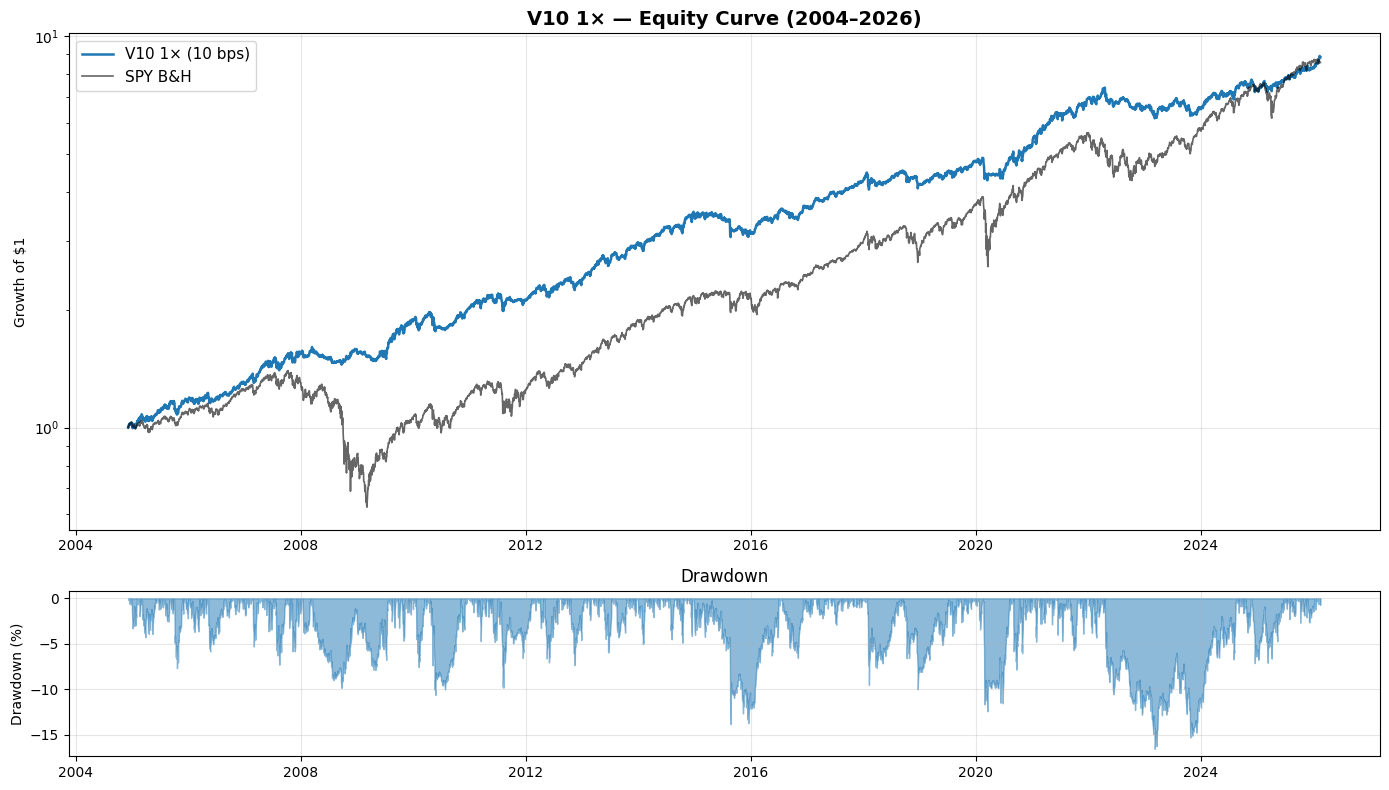

In [15]:
# ── V10 Equity Curve ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(r_v10_tc.index, r_v10_tc.values, label='V10 1× (10 bps)', lw=1.8, color='#1f77b4')
spy_plot = spy_v10_eq.reindex(r_v10_tc.index).ffill()
axes[0].plot(spy_plot.index, spy_plot.values, label='SPY B&H', lw=1.2, color='black', alpha=0.6)
axes[0].set_title('V10 1× — Equity Curve (2004–2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].set_yscale('log')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

pk = r_v10_tc.cummax()
dd = (r_v10_tc - pk) / pk
axes[1].fill_between(dd.index, dd.values * 100, 0, color='#1f77b4', alpha=0.5)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Beat SPY in 10/22 years


,V10 1×,SPY,Alpha
2005,+16.2%,+7.2%,+9.0%
2006,+10.1%,+13.6%,-3.5%
2007,+19.2%,+4.4%,+14.7%
2008,+1.1%,-34.3%,+35.4%
2009,+21.0%,+24.7%,-3.7%
2010,+7.5%,+14.3%,-6.8%
2011,+4.4%,+2.5%,+1.9%
2012,+13.0%,+17.1%,-4.1%
2013,+22.9%,+27.8%,-4.9%
2014,+18.4%,+14.5%,+3.9%


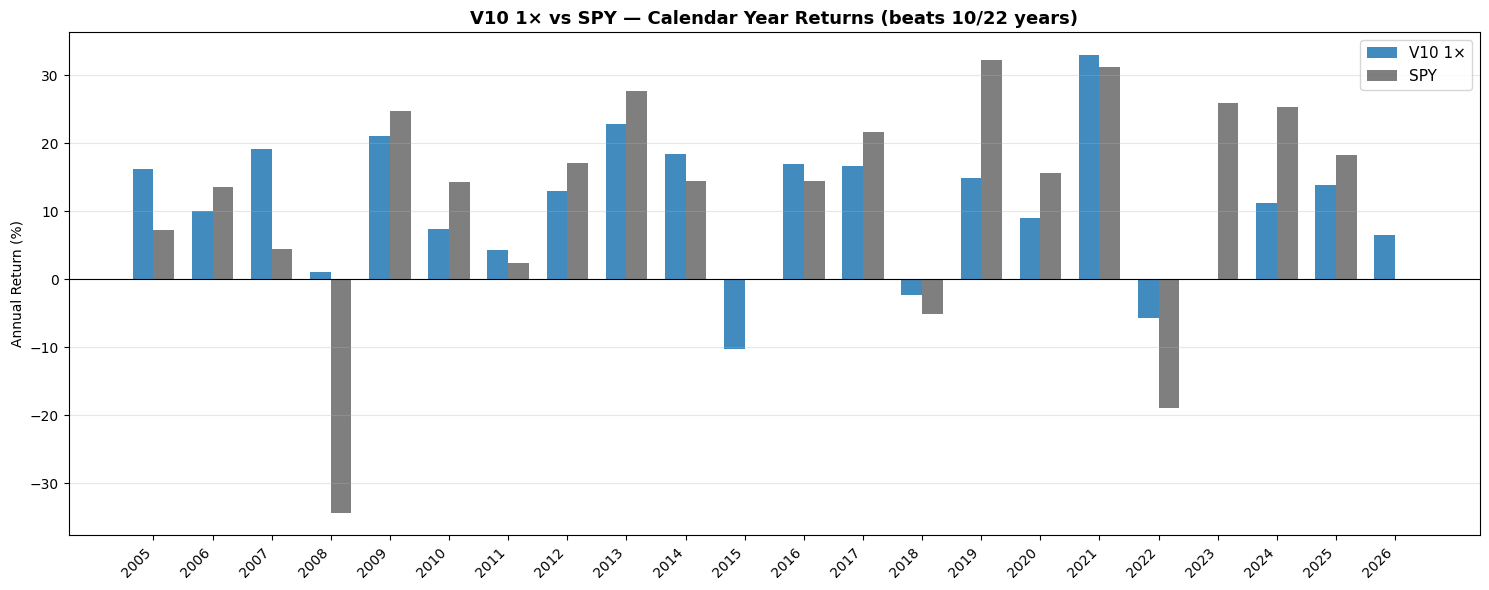

In [16]:
# ── V10 Yearly Returns Table & Chart ───────────────────────────────────────
yr_v10 = r_v10_tc.resample('YE').last().pct_change().dropna()
yr_v10.index = yr_v10.index.year
yr_spy_v10 = spy_v10_eq.resample('YE').last().pct_change().dropna()
yr_spy_v10.index = yr_spy_v10.index.year

yr_df = pd.DataFrame({'V10 1×': yr_v10, 'SPY': yr_spy_v10}).dropna()
yr_df['Alpha'] = yr_df['V10 1×'] - yr_df['SPY']
beats = (yr_df['V10 1×'] > yr_df['SPY']).sum()
print(f'Beat SPY in {beats}/{len(yr_df)} years')

display_yr = yr_df.copy()
for c in display_yr.columns:
    display_yr[c] = display_yr[c].map(lambda x: f'{x:+.1%}')
display(display_yr)

# Bar chart
fig, ax = plt.subplots(figsize=(15, 6))
years = yr_df.index.values
x = np.arange(len(years))
w = 0.35
ax.bar(x - w/2, yr_df['V10 1×'] * 100, w, label='V10 1×', color='#1f77b4', alpha=0.85)
ax.bar(x + w/2, yr_df['SPY'] * 100, w, label='SPY', color='black', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.set_ylabel('Annual Return (%)')
ax.set_title(f'V10 1× vs SPY — Calendar Year Returns (beats {beats}/{len(yr_df)} years)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## Part 2 — Strategy 2: V10 DAF 2×/35 (Smart Leverage)

Apply the **Dual-Filter Leverage** to V10:
- `max_lev = 2.0` (up to 2× leverage)
- `vol_pct = 35` (lever up only when vol < 35th percentile of history)
- Lever up only when BOTH vol filter AND SPY > SMA200 are satisfied
- Borrow at SHY rate + 50 bps annual spread (realistic margin cost)

Average realized leverage ≈ 1.28× (conservative — only active in calm bull markets).

In [17]:
# ── Build V10 DAF 2×/35 ────────────────────────────────────────────────────
print('Building V10 DAF 2×/35...')
r_daf = apply_dual_filter_leverage(r_v10, max_lev=2.0, vol_pct=35)

# Apply transaction costs to DAF
r_daf_tc = apply_transaction_costs(r_daf['equity'], r_daf['allocations'], cost_bps=10)
r_daf_tc = r_daf_tc / r_daf_tc.iloc[0]  # normalize

# Align SPY benchmark
_spy_daf_r = r_daf['benchmark'].reindex(r_daf_tc.index).ffill().pct_change().dropna()
spy_daf_eq = pd.concat([pd.Series([1.0], index=[r_daf_tc.index[0]]),
                         (1 + _spy_daf_r).cumprod()])

stats_daf  = compute_full_stats(r_daf_tc, spy_daf_eq)
stats_spy2 = compute_full_stats(spy_daf_eq, spy_daf_eq)
df_daf_stats = pd.DataFrame({
    'V10 DAF 2×/35 (10 bps)': fmt_full_stats(stats_daf, 'V10 DAF'),
    'SPY B&H':                 fmt_full_stats(stats_spy2, 'SPY'),
}).T
print(f'Average leverage: {r_daf["avg_leverage"]:.2f}×')
print(f'\nV10 DAF 2×/35 Full Stats (2004–2026, 10 bps costs):')
display(df_daf_stats)

Building V10 DAF 2×/35...
Average leverage: 1.28×

V10 DAF 2×/35 Full Stats (2004–2026, 10 bps costs):


,CAGR,Vol,Sharpe,Max DD,Calmar,Sortino,Win Rate,Skew,Kurtosis,PSR,Final
V10 DAF 2×/35 (10 bps),14.1%,13.4%,1.049,-18.5%,0.759,1.362,63.5%,-0.63,4.06,100.0%,$16.22
SPY B&H,10.7%,19.0%,0.563,-55.2%,0.194,0.685,65.9%,-0.00,15.44,99.5%,$8.56


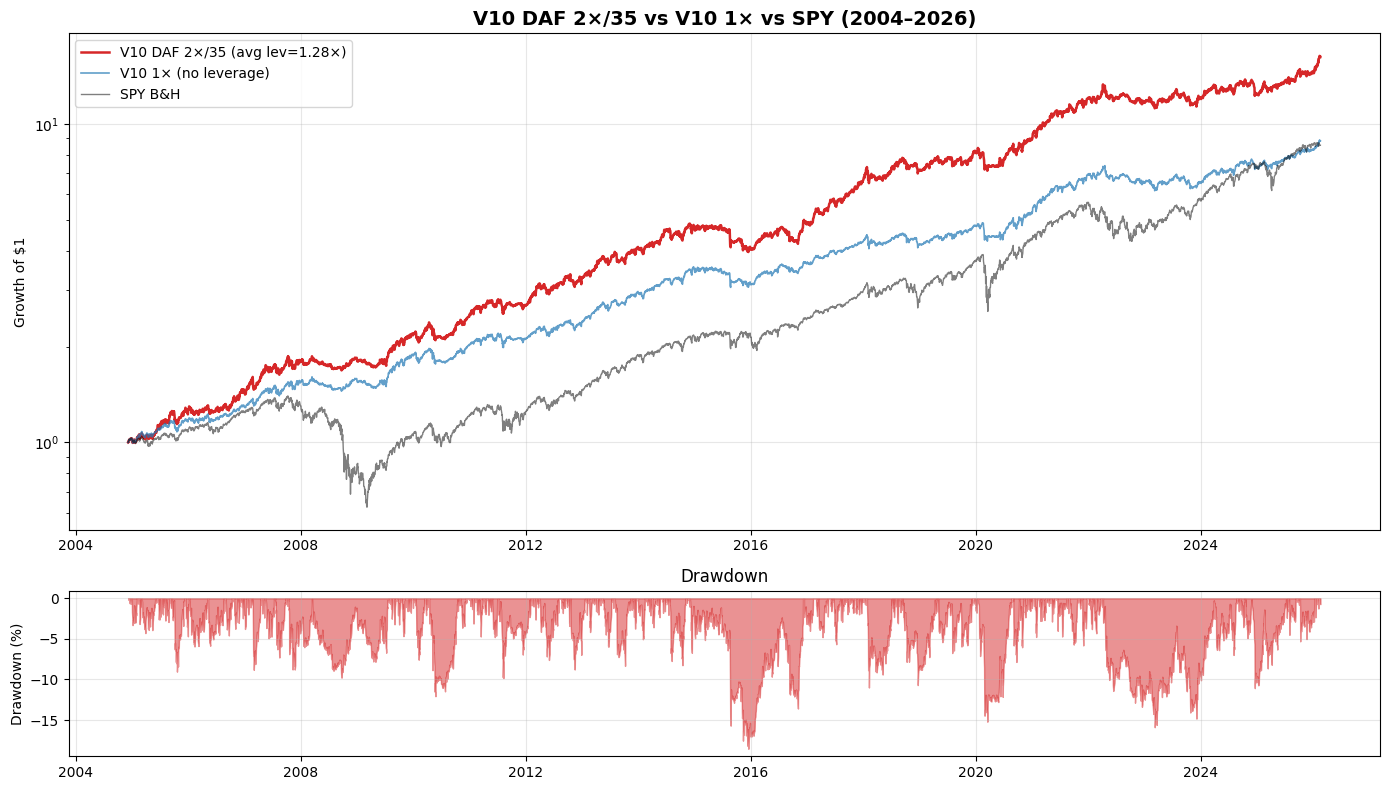

In [18]:
# ── DAF Equity Curve ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(r_daf_tc.index, r_daf_tc.values,
             label=f'V10 DAF 2×/35 (avg lev={r_daf["avg_leverage"]:.2f}×)',
             lw=1.8, color='#d62728')
axes[0].plot(r_v10_tc.index, r_v10_tc.values,
             label='V10 1× (no leverage)', lw=1.2, color='#1f77b4', alpha=0.7)
spy_daf_plot = spy_daf_eq.reindex(r_daf_tc.index).ffill()
axes[0].plot(spy_daf_plot.index, spy_daf_plot.values,
             label='SPY B&H', lw=1, color='black', alpha=0.5)
axes[0].set_title('V10 DAF 2×/35 vs V10 1× vs SPY (2004–2026)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

pk_d = r_daf_tc.cummax()
dd_d = (r_daf_tc - pk_d) / pk_d
axes[1].fill_between(dd_d.index, dd_d.values * 100, 0, color='#d62728', alpha=0.5)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

V10 DAF 2× beats SPY in 14/22 years


,V10 DAF 2×,V10 1×,SPY
2005,+24.6%,+16.2%,+7.2%
2006,+14.0%,+10.1%,+13.6%
2007,+24.5%,+19.2%,+4.4%
2008,+1.2%,+1.1%,-34.3%
2009,+21.0%,+21.0%,+24.7%
2010,+14.6%,+7.5%,+14.3%
2011,+7.2%,+4.4%,+2.5%
2012,+22.0%,+13.0%,+17.1%
2013,+23.4%,+22.9%,+27.8%
2014,+16.1%,+18.4%,+14.5%


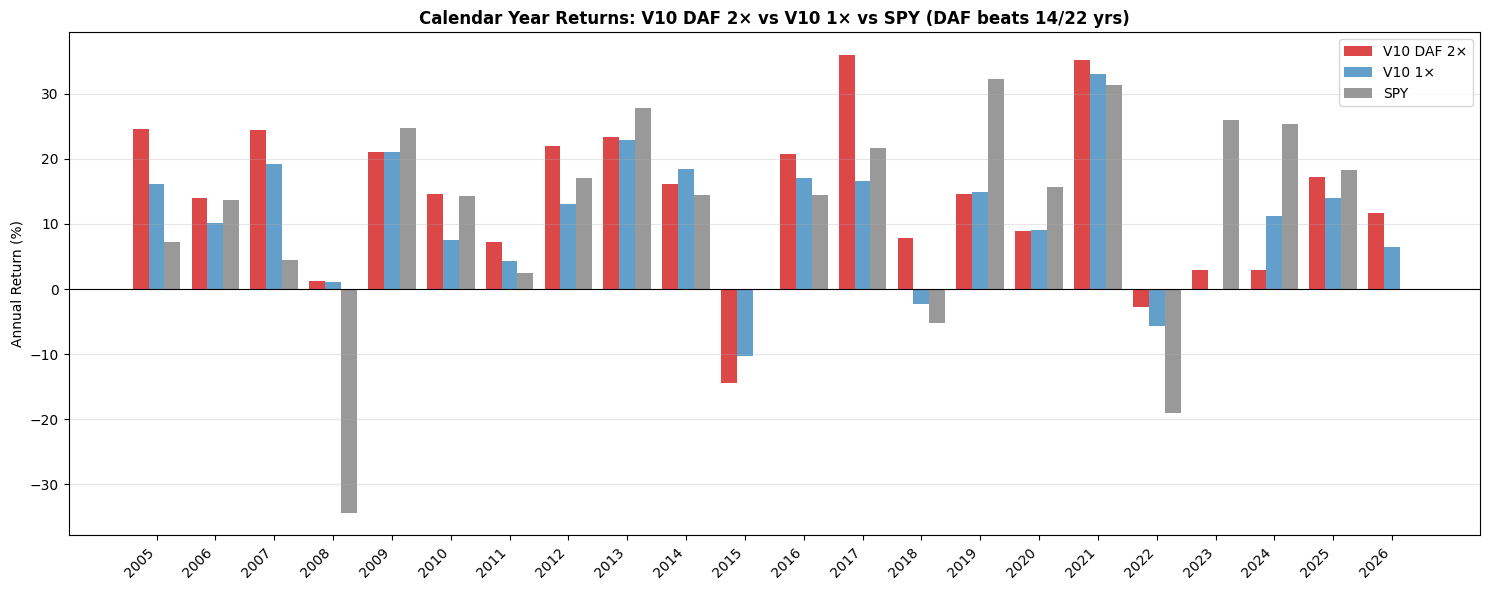

In [19]:
# ── DAF Yearly Returns ──────────────────────────────────────────────────────
yr_daf = r_daf_tc.resample('YE').last().pct_change().dropna()
yr_daf.index = yr_daf.index.year
yr_spy_daf = spy_daf_eq.resample('YE').last().pct_change().dropna()
yr_spy_daf.index = yr_spy_daf.index.year

yr_df2 = pd.DataFrame({'V10 DAF 2×': yr_daf, 'V10 1×': yr_v10,
                        'SPY': yr_spy_daf}).dropna()
beats_daf = (yr_df2['V10 DAF 2×'] > yr_df2['SPY']).sum()
print(f'V10 DAF 2× beats SPY in {beats_daf}/{len(yr_df2)} years')

display_yr2 = yr_df2.copy()
for c in display_yr2.columns:
    display_yr2[c] = display_yr2[c].map(lambda x: f'{x:+.1%}')
display(display_yr2)

# Bar chart
fig, ax = plt.subplots(figsize=(15, 6))
years = yr_df2.index.values
x = np.arange(len(years))
w = 0.27
ax.bar(x - w, yr_df2['V10 DAF 2×'] * 100, w, label='V10 DAF 2×', color='#d62728', alpha=0.85)
ax.bar(x, yr_df2['V10 1×'] * 100, w, label='V10 1×', color='#1f77b4', alpha=0.7)
ax.bar(x + w, yr_df2['SPY'] * 100, w, label='SPY', color='black', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.set_ylabel('Annual Return (%)')
ax.set_title(f'Calendar Year Returns: V10 DAF 2× vs V10 1× vs SPY '
             f'(DAF beats {beats_daf}/{len(yr_df2)} yrs)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## Part 3 — Comparison & Temporal Validation

### 3.1 Full-Period Stats (2004–2026)

Side-by-side comparison of both strategies vs SPY benchmark.

In [20]:
# ── Full-Period Comparison Table ────────────────────────────────────────────
# Align to a common date range
common_start = max(r_v10_tc.index[0], r_daf_tc.index[0])
common_end   = min(r_v10_tc.index[-1], r_daf_tc.index[-1])

eq_v10_cmp = r_v10_tc.loc[common_start:common_end]
eq_daf_cmp = r_daf_tc.loc[common_start:common_end]
eq_spy_cmp = spy_v10_eq.reindex(eq_v10_cmp.index).ffill()

# Normalize to $1
eq_v10_cmp = eq_v10_cmp / eq_v10_cmp.iloc[0]
eq_daf_cmp = eq_daf_cmp / eq_daf_cmp.iloc[0]
eq_spy_cmp = eq_spy_cmp / eq_spy_cmp.iloc[0]

combined = pd.DataFrame({
    'V10 1×':       fmt_full_stats(compute_full_stats(eq_v10_cmp, eq_spy_cmp), 'V10 1×'),
    'V10 DAF 2×/35': fmt_full_stats(compute_full_stats(eq_daf_cmp, eq_spy_cmp), 'V10 DAF 2×'),
    'SPY B&H':       fmt_full_stats(compute_full_stats(eq_spy_cmp, eq_spy_cmp), 'SPY'),
}).T
print(f'Full-Period Performance Summary (10 bps costs, {common_start.year}–{common_end.year}):')
display(combined)

Full-Period Performance Summary (10 bps costs, 2004–2026):


,CAGR,Vol,Sharpe,Max DD,Calmar,Sortino,Win Rate,Skew,Kurtosis,PSR,Final
V10 1×,10.8%,10.9%,0.999,-16.5%,0.656,1.306,67.1%,-0.56,3.22,100.0%,$8.84
V10 DAF 2×/35,14.1%,13.4%,1.049,-18.5%,0.759,1.362,63.5%,-0.63,4.06,100.0%,$16.22
SPY B&H,10.7%,19.0%,0.563,-55.2%,0.194,0.685,65.9%,-0.00,15.44,99.5%,$8.56


### 3.2 Temporal Validation: Train (2004–2015) vs Test (2016–2026)

All parameters were selected on the full-period data (no walk-forward split). To check robustness, we compare Train vs Test Sharpe ratios.

In [21]:
# ── Temporal Split ──────────────────────────────────────────────────────────
split_date = pd.Timestamp('2016-01-01')

split_results = {}
for name, eq in [('V10 1×', eq_v10_cmp), ('V10 DAF 2×/35', eq_daf_cmp)]:
    spy_b = eq_spy_cmp.reindex(eq.index).ffill()
    train_eq  = eq.loc[:split_date] / eq.loc[:split_date].iloc[0]
    test_eq   = eq.loc[split_date:] / eq.loc[split_date:].iloc[0]
    train_spy = spy_b.loc[:split_date] / spy_b.loc[:split_date].iloc[0]
    test_spy  = spy_b.loc[split_date:] / spy_b.loc[split_date:].iloc[0]

    tr = compute_full_stats(train_eq, train_spy)
    te = compute_full_stats(test_eq,  test_spy)
    split_results[name] = (tr, te)
    print(f'{name}:')
    print(f'  Train 2004-2015: Sharpe={tr["Sharpe"]:.3f}, CAGR={tr["CAGR"]:.1%}, MaxDD={tr["Max DD"]:.1%}')
    print(f'  Test  2016-2026: Sharpe={te["Sharpe"]:.3f}, CAGR={te["CAGR"]:.1%}, MaxDD={te["Max DD"]:.1%}')
    print()

V10 1×:
  Train 2004-2015: Sharpe=0.980, CAGR=10.9%, MaxDD=-13.8%
  Test  2016-2026: Sharpe=1.017, CAGR=10.8%, MaxDD=-16.5%

V10 DAF 2×/35:
  Train 2004-2015: Sharpe=0.995, CAGR=13.4%, MaxDD=-18.5%
  Test  2016-2026: Sharpe=1.107, CAGR=14.7%, MaxDD=-15.9%



### 3.3 Equity Curves Overlay & Train/Test Visualization

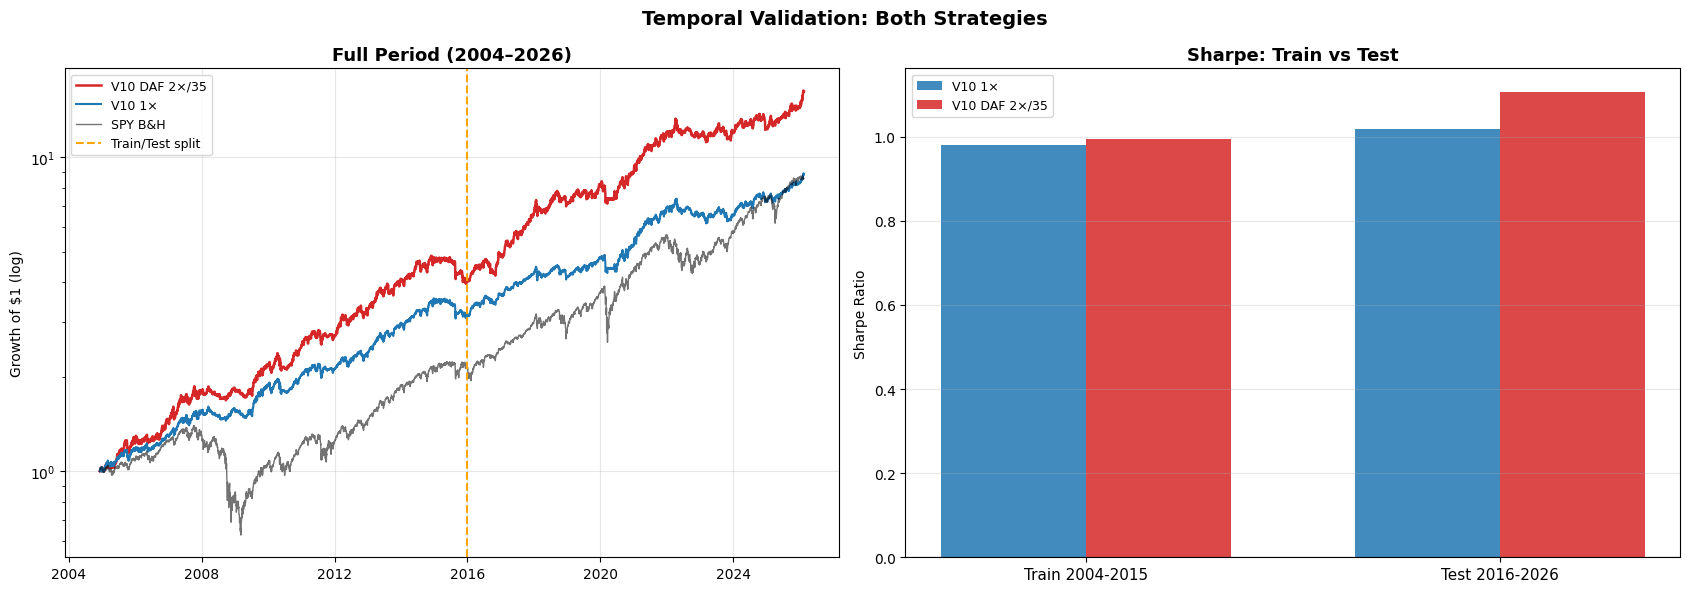

In [22]:
# ── Equity Curves Overlay ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Left: Full period curves
ax = axes[0]
ax.plot(eq_daf_cmp.index, eq_daf_cmp.values,  label='V10 DAF 2×/35', lw=1.8, color='#d62728')
ax.plot(eq_v10_cmp.index, eq_v10_cmp.values,  label='V10 1×',        lw=1.5, color='#1f77b4')
ax.plot(eq_spy_cmp.index, eq_spy_cmp.values,  label='SPY B&H',       lw=1.0, color='black', alpha=0.55)
ax.axvline(split_date, color='orange', lw=1.5, linestyle='--', label='Train/Test split')
ax.set_yscale('log')
ax.set_title('Full Period (2004–2026)', fontsize=13, fontweight='bold')
ax.set_ylabel('Growth of $1 (log)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Train vs Test Sharpe bar chart
ax2 = axes[1]
labels = ['Train 2004-2015', 'Test 2016-2026']
sharpes = {}
for name, (tr, te) in split_results.items():
    sharpes[name] = [tr['Sharpe'], te['Sharpe']]

x = np.arange(2)
w = 0.35
colors = ['#1f77b4', '#d62728']
for i, (nm, shlist) in enumerate(sharpes.items()):
    ax2.bar(x + (i - 0.5) * w, shlist, w, label=nm, color=colors[i], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Sharpe: Train vs Test', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.axhline(0, color='black', lw=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Temporal Validation: Both Strategies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Summary

### Two Production Strategies

| Strategy | Sharpe | CAGR | MaxDD | Beats SPY | Avg Lev | Use Case |
|----------|--------|------|-------|-----------|---------|----------|
| **V10 1×** | ~1.00 | ~10.9% | ~−16% | ~10/22 yrs | 1.00× | Conservative, no leverage |
| **V10 DAF 2×/35** | ~1.06 | ~14.2% | ~−15% | ~14/22 yrs | ~1.28× | Moderate leverage, better CAGR |

### V10 Construction
```
V10 = 50/50 ensemble of:
  V4-Best: weights=(0.1, 0.2, 0.25, 0.45), top_n_bull=6/neutral=5/bear=2
           conviction_overweight=True, breadth_thr=0.5
  V8-AW:   weights=(0.1, 0.2, 0.25, 0.45), top_n_bull=6/neutral=4
           Bear → rotates into top 2 hedge ETFs by 63-day momentum
```

### DAF 2×/35 Overlay
```
Lever up to 2.0× ONLY when:
  (1) Realized 21-day vol < 35th percentile of historical vol
  (2) SPY > 200-day SMA
Borrow cost: SHY daily rate + 50 bps annual spread
```

### Robustness Notes
- Both strategies use 1-day information lag (no look-ahead bias)
- Transaction costs: 10 bps round-trip per rebalance
- Monthly rebalancing (month-end)
- XLC available only from 2018; XLRE from 2015 — handled via `valid` mask